In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load DEG lists without headers
up_genes = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/mega_upregulated_withall3_log2fc.tsv", sep="\t")
down_genes = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/mega_downregulated_withall3_log2fc.tsv", sep="\t")

# Assign column name
#up_genes.columns = ["hgnc_symbol"]
#down_genes.columns = ["hgnc_symbol"]

# Extract gene symbol lists
up_gene_list = up_genes["hgnc_symbol"].dropna().unique().tolist()
down_gene_list = down_genes["hgnc_symbol"].dropna().unique().tolist()

genes_of_int = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/merged_loops_with_genes.tsv", sep="\t")

# Your list of 56 genes
genes_of_interest = genes_of_int["gene_symbol"]

# Remove duplicates
genes_of_interest = list(set(genes_of_interest))

# Classify each gene
def get_deg_status(gene):
    if gene in up_gene_list:
        return "up"
    elif gene in down_gene_list:
        return "down"
    else:
        return "not_deg"

# Build DataFrame
comparison_df = pd.DataFrame({
    "hgnc_symbol": genes_of_interest,
    "deg_status": [get_deg_status(g) for g in genes_of_interest]
})

# Merge log2fc values into comparison_df
comparison_df = comparison_df.merge(
    up_genes[['hgnc_symbol', 'log2fc_exon', 'log2fc_intron', 'log2fc_deseq']],
    on='hgnc_symbol',
    how='left'
)

#combined_log2fc = pd.concat([up_genes, down_genes], axis=0)
#comparison_df = comparison_df.merge(
#    combined_log2fc[['hgnc_symbol', 'log2fc_exon', 'log2fc_intron', 'log2fc_deseq']],
#    on='hgnc_symbol',
#    how='left'
#)


print(comparison_df.sort_values("deg_status"))


    hgnc_symbol deg_status  log2fc_exon  log2fc_intron  log2fc_deseq
102       EFNA5       down          NaN            NaN           NaN
31        CASP6       down          NaN            NaN           NaN
37        CCNE2       down          NaN            NaN           NaN
71         PKD1       down          NaN            NaN           NaN
26        TNNI2       down          NaN            NaN           NaN
..          ...        ...          ...            ...           ...
32        LTBP1         up          NaN            NaN      0.682561
30      COL13A1         up          NaN            NaN      0.771736
29        SORT1         up     0.617458            NaN      0.704850
41    LINC00880         up          NaN            NaN      0.915040
51       AKR1C3         up          NaN            NaN      0.605034

[103 rows x 5 columns]


In [3]:
#up_genes.head()

---

In [4]:
comparison_df[comparison_df["deg_status"] == "down"]

,hgnc_symbol,deg_status,log2fc_exon,log2fc_intron,log2fc_deseq
6,ARVCF,down,NaN,NaN,NaN
11,MDM1,down,NaN,NaN,NaN
24,SEMA3B,down,NaN,NaN,NaN
26,TNNI2,down,NaN,NaN,NaN
31,CASP6,down,NaN,NaN,NaN
35,MMD,down,NaN,NaN,NaN
37,CCNE2,down,NaN,NaN,NaN
43,HDAC10,down,NaN,NaN,NaN
46,JAG2,down,NaN,NaN,NaN
49,GOLGA8A,down,NaN,NaN,NaN


In [5]:
len(comparison_df[comparison_df["deg_status"] == "down"])

23

In [6]:
comparison_df[comparison_df["deg_status"] == "up"]

,hgnc_symbol,deg_status,log2fc_exon,log2fc_intron,log2fc_deseq
0,HK1,up,0.700507,NaN,0.746001
1,FAT1,up,NaN,0.623353,NaN
2,CDH3,up,NaN,NaN,0.615961
3,ARHGEF4,up,NaN,0.715679,NaN
4,MEI1,up,NaN,0.772600,NaN
...,...,...,...,...,...
96,SEPTIN9,up,0.606580,NaN,0.602054
97,ZFP36L2,up,NaN,NaN,0.650165
98,CCDC124,up,0.627202,NaN,NaN
100,CYB5R3,up,0.730068,NaN,NaN


In [7]:
len(comparison_df[comparison_df["deg_status"] == "up"])

77

In [8]:
comparison_df[comparison_df["deg_status"] == "not_deg"]

,hgnc_symbol,deg_status,log2fc_exon,log2fc_intron,log2fc_deseq
22,NaN,not_deg,NaN,NaN,NaN
58,MAPK12,not_deg,NaN,NaN,NaN
84,MMP24OS,not_deg,NaN,NaN,NaN


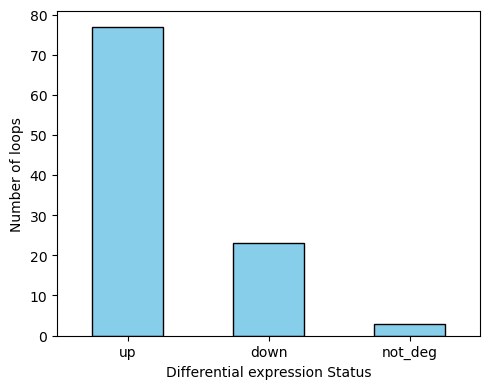

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Your dataframe: comparison_df
# Count each DEG status
status_counts = comparison_df["deg_status"].value_counts()

# Plot
plt.figure(figsize=(5, 4))
status_counts.plot(kind="bar", color="skyblue", edgecolor="black")
#plt.title("DEG Status Distribution")
plt.xlabel("Differential expression Status")
plt.ylabel("Number of loops")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


----

In [10]:
# Next to do - plot

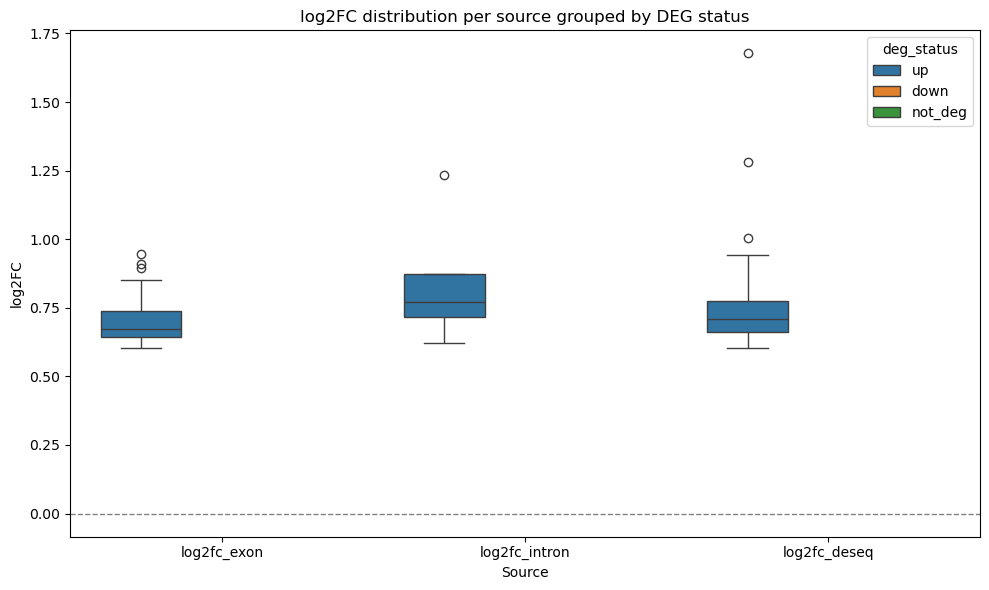

In [11]:
# think about the utility of the plot
# Melt the DataFrame to long format
melted = comparison_df.melt(
    id_vars='deg_status',
    value_vars=['log2fc_exon', 'log2fc_intron', 'log2fc_deseq'],
    var_name='source',
    value_name='log2fc'
)

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=melted, x='source', y='log2fc', hue='deg_status')
plt.title("log2FC distribution per source grouped by DEG status")
plt.ylabel("log2FC")
plt.xlabel("Source")
plt.axhline(0, linestyle='--', color='grey', linewidth=1)
plt.tight_layout()
plt.show()


In [12]:
comparison_df

,hgnc_symbol,deg_status,log2fc_exon,log2fc_intron,log2fc_deseq
0,HK1,up,0.700507,NaN,0.746001
1,FAT1,up,NaN,0.623353,NaN
2,CDH3,up,NaN,NaN,0.615961
3,ARHGEF4,up,NaN,0.715679,NaN
4,MEI1,up,NaN,0.772600,NaN
...,...,...,...,...,...
98,CCDC124,up,0.627202,NaN,NaN
99,SYT8,down,NaN,NaN,NaN
100,CYB5R3,up,0.730068,NaN,NaN
101,TNS4,up,0.693462,NaN,0.750104


In [13]:
final_loops = pd.read_csv("merged_loops_with_genes.tsv", sep="\t")
final_loops

,tss_chr,tss_start,tss_end,gene_id_x,score,strand,anchor_chr,anchor_start,anchor_end,tss_anchor,...,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end,gene_id_y,gene_symbol
0,chr16,69754416,69755417,ENST00000562416.1,0,-,chr16,69750000,69755000,2,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000562416,NOB1
1,chr16,69754291,69755292,ENST00000563055.1,0,-,chr16,69750000,69755000,2,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000563055,NOB1
2,chr16,69751752,69752753,ENST00000561677.6,0,-,chr16,69750000,69755000,2,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000561677,NOB1
3,chr16,69754425,69755426,ENST00000268802.10,0,-,chr16,69750000,69755000,2,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000268802,NOB1
4,chr16,69754413,69755414,ENST00000564620.5,0,-,chr16,69750000,69755000,2,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000564620,NOB1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,chr3,124927270,124928271,ENST00000490147.1,0,-,chr3,124922500,124927500,1,...,0.511961,0.424292,0.413881,0.091242,-0.010410,chr3,125582500,125587500,ENST00000490147,MUC13
621,chr12,68325609,68326610,ENST00000540476.5,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,NaN,chr12,67352500,67357500,ENST00000540476,MDM1
622,chr12,68322711,68323712,ENST00000538454.2,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,NaN,chr12,67352500,67357500,ENST00000538454,MDM1
623,chr12,68322897,68323898,ENST00000536997.1,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,NaN,chr12,67352500,67357500,ENST00000536997,MDM1
